In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
data = pd.read_csv("data/Telco-Customer-Churn.csv")

In [8]:
data.shape

(7043, 21)

In [9]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
data['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [13]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [17]:
data['TotalCharges'].head(10)

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: object

In [18]:
data['TotalCharges'].tail(10)

7033    2625.25
7034    6886.25
7035     1495.1
7036      743.3
7037     1419.4
7038     1990.5
7039     7362.9
7040     346.45
7041      306.6
7042     6844.5
Name: TotalCharges, dtype: object

In [19]:
data['TotalCharges'].str.strip().eq("").sum()

np.int64(11)

In [20]:
data[data['TotalCharges'].str.strip()==""]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [26]:
data['TotalCharges'] = data['TotalCharges'].mask(data['TotalCharges'].str.strip()=="",np.nan)

In [27]:
data['TotalCharges'].isnull().sum()

np.int64(11)

In [28]:
data['TotalCharges'] = data['TotalCharges'].fillna(0)

In [29]:
data['TotalCharges'].isnull().sum()

np.int64(0)

In [30]:
data['TotalCharges'].dtype

dtype('O')

In [31]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'])

In [32]:
data['TotalCharges'].dtype

dtype('float64')

In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [34]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

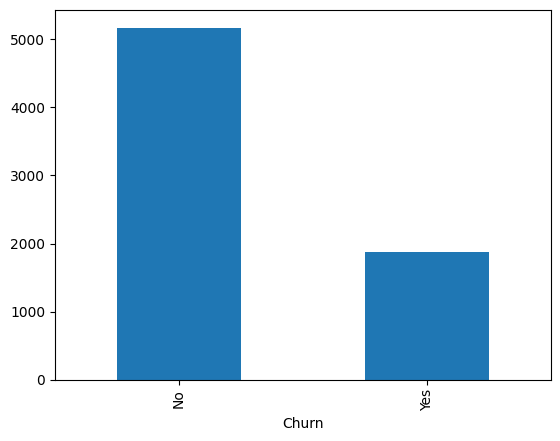

In [37]:
data['Churn'].value_counts().plot(kind="bar")
plt.show()

In [39]:
pd.crosstab(data["Contract"],data["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [40]:
pd.crosstab(data["Contract"],data["Churn"],normalize="index")

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


In [42]:
data.groupby("Churn")["tenure"].mean()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

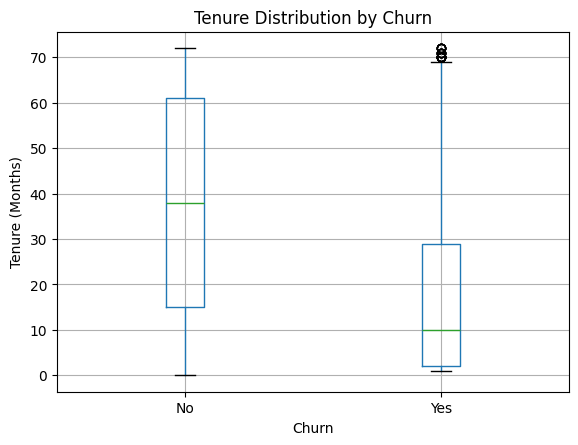

In [45]:
data.boxplot(column="tenure",by="Churn")
plt.title("Tenure Distribution by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

In [46]:
data.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

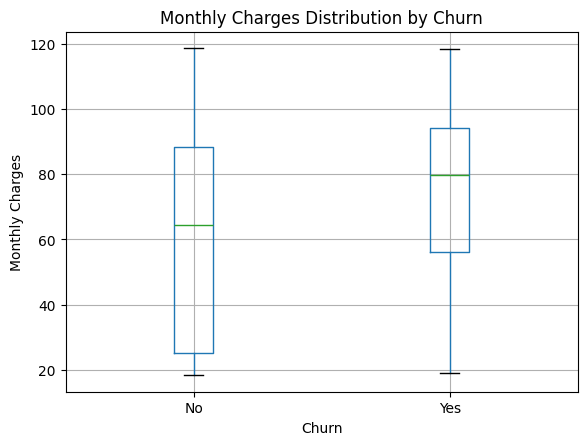

In [47]:
data.boxplot(column="MonthlyCharges", by="Churn")
plt.title("Monthly Charges Distribution by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

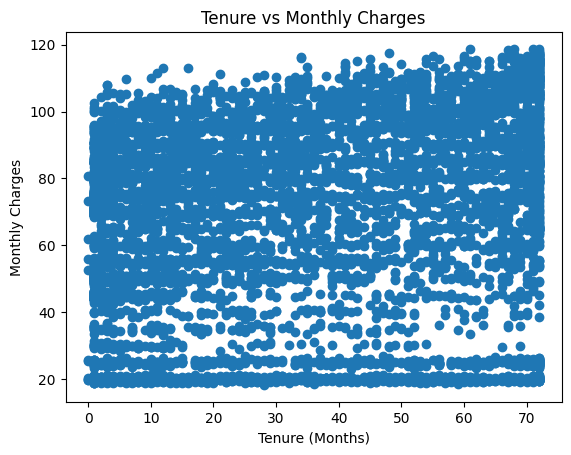

In [48]:
plt.scatter(data["tenure"], data["MonthlyCharges"])

plt.title("Tenure vs Monthly Charges")
plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges")
plt.show()

In [49]:
data["tenure"].corr(data["MonthlyCharges"])

np.float64(0.24789985628615008)

In [50]:
pd.crosstab(data["InternetService"],data["Churn"])

Churn,No,Yes
InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


In [52]:
pd.crosstab(data["InternetService"],data["Churn"],normalize="index")

Churn,No,Yes
InternetService,,
DSL,0.810409,0.189591
Fiber optic,0.581072,0.418928
No,0.925950,0.074050


In [53]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [54]:
pd.crosstab(data["PaymentMethod"],data["Churn"])

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


In [55]:
pd.crosstab(data["PaymentMethod"],data["Churn"],normalize="index")

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),0.832902,0.167098
Credit card (automatic),0.847569,0.152431
Electronic check,0.547146,0.452854
Mailed check,0.808933,0.191067


In [56]:
pd.crosstab(
    [data["PaymentMethod"], data["Contract"]],
    data["Churn"],
    normalize="index"
)

Churn                                           No       Yes
PaymentMethod             Contract                          
Bank transfer (automatic) Month-to-month  0.658744  0.341256
                          One year        0.902813  0.097187
                          Two year        0.966312  0.033688
Credit card (automatic)   Month-to-month  0.672192  0.327808
                          One year        0.896985  0.103015
                          Two year        0.977625  0.022375
Electronic check          Month-to-month  0.462703  0.537297
                          One year        0.815562  0.184438
                          Two year        0.922619  0.077381
Mailed check              Month-to-month  0.684211  0.315789
                          One year        0.931751  0.068249
                          Two year        0.992147  0.007853

In [57]:
data[
    (data["PaymentMethod"] == "Electronic check") &
    (data["Contract"] == "Month-to-month") &
    (data["Churn"] == "Yes")
]["tenure"].mean()

np.float64(14.14486921529175)

In [58]:
data[
    (data["PaymentMethod"] == "Electronic check") &
    (data["Contract"] == "Month-to-month") &
    (data["Churn"] == "No")
]["tenure"].mean()

np.float64(22.414719626168225)

In [59]:
pd.crosstab(data["SeniorCitizen"],data["Churn"],normalize="index")

Churn,No,Yes
SeniorCitizen,,
0,0.763938,0.236062
1,0.583187,0.416813


In [60]:
pd.crosstab(data["OnlineSecurity"],data["Churn"],normalize="index")

Churn,No,Yes
OnlineSecurity,,
No,0.582333,0.417667
No internet service,0.925950,0.074050
Yes,0.853888,0.146112


In [61]:
pd.crosstab(data["TechSupport"],data["Churn"],normalize="index")

Churn,No,Yes
TechSupport,,
No,0.583645,0.416355
No internet service,0.925950,0.074050
Yes,0.848337,0.151663


In [63]:
X = data.drop(["customerID","Churn"],axis=1)
y = data["Churn"]

In [64]:
X.shape

(7043, 19)

In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [74]:
X_train.shape


(5634, 19)

In [75]:
X_test.shape

(1409, 19)

In [79]:
y_train.shape

(5634,)

In [80]:
y_test.shape

(1409,)

In [81]:
X_train.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
dtype: object

In [82]:
X_train["Contract"].unique()

array(['Month-to-month', 'Two year', 'One year'], dtype=object)

In [83]:
X_train["PaymentMethod"].unique()

array(['Electronic check', 'Mailed check', 'Credit card (automatic)',
       'Bank transfer (automatic)'], dtype=object)

In [84]:
X_train["InternetService"].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [85]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [86]:
numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [87]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [88]:
X_train_encoded = preprocessor.fit_transform(X_train)

In [89]:
X_test_encoded = preprocessor.transform(X_test)

In [90]:
X_train_encoded.shape
X_test_encoded.shape

(1409, 46)

In [91]:
y_train = y_train.map({"No": 0, "Yes": 1})
y_test = y_test.map({"No": 0, "Yes": 1})

In [92]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

In [93]:
model.fit(X_train_encoded, y_train)

C:\Users\Tony Ashraf\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [94]:
y_pred = model.predict(X_test_encoded)

In [95]:
y_pred[:20]

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0])

In [96]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8048261178140526


In [97]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[925 110]
 [165 209]]


In [98]:
confusion_matrix(y_test, y_pred)

array([[925, 110],
       [165, 209]])

In [99]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [100]:
y_prob = model.predict_proba(X_test_encoded)[:, 1]

In [101]:
y_prob[:20]

array([0.04587261, 0.68281419, 0.06300906, 0.39011207, 0.02025049,
       0.60132192, 0.44115215, 0.1264443 , 0.00262147, 0.39556598,
       0.27594471, 0.06341023, 0.12574438, 0.68404767, 0.12541481,
       0.05695429, 0.03224287, 0.64157808, 0.18522842, 0.08548399])

In [102]:
y_pred_04 = (y_prob >= 0.4).astype(int)

In [103]:
print(classification_report(y_test, y_pred_04))

              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1035
           1       0.57      0.67      0.62       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



In [104]:
import numpy as np

for threshold in np.arange(0.1, 1.0, 0.1):
    y_pred_threshold = (y_prob >= threshold).astype(int)
    
    report = classification_report(
        y_test,
        y_pred_threshold,
        output_dict=True
    )
    
    print(
        f"Threshold: {threshold:.1f} | "
        f"Precision: {report['1']['precision']:.2f} | "
        f"Recall: {report['1']['recall']:.2f} | "
        f"F1: {report['1']['f1-score']:.2f}"
    )

Threshold: 0.1 | Precision: 0.41 | Recall: 0.95 | F1: 0.57
Threshold: 0.2 | Precision: 0.47 | Recall: 0.86 | F1: 0.61
Threshold: 0.3 | Precision: 0.52 | Recall: 0.76 | F1: 0.62
Threshold: 0.4 | Precision: 0.57 | Recall: 0.67 | F1: 0.62
Threshold: 0.5 | Precision: 0.66 | Recall: 0.56 | F1: 0.60
Threshold: 0.6 | Precision: 0.72 | Recall: 0.40 | F1: 0.52
Threshold: 0.7 | Precision: 0.74 | Recall: 0.18 | F1: 0.30
Threshold: 0.8 | Precision: 0.75 | Recall: 0.02 | F1: 0.05
Threshold: 0.9 | Precision: 0.00 | Recall: 0.00 | F1: 0.00


C:\Users\Tony Ashraf\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Tony Ashraf\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Tony Ashraf\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_

In [105]:
from sklearn.ensemble import RandomForestClassifier

In [106]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [107]:
rf_model.fit(X_train_encoded, y_train)

RandomForestClassifier(random_state=42)

In [108]:
rf_pred = rf_model.predict(X_test_encoded)

In [109]:
rf_pred[:20]

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0])

In [110]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7821149751596878


In [111]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.61      0.49      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



In [112]:
rf_cm = confusion_matrix(y_test, rf_pred)

print(rf_cm)

[[920 115]
 [192 182]]


In [113]:
from sklearn.model_selection import RandomizedSearchCV

In [114]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [115]:
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

In [116]:
random_search.fit(X_train_encoded, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [None, 5, 10, 15, 20],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, scoring='f1')

In [117]:
random_search.best_params_

{'n_estimators': 200,
 'min_samples_split': 5,
 'min_samples_leaf': 2,
 'max_depth': 10}

In [118]:
random_search.best_score_

np.float64(0.5775928642121899)

In [119]:
best_rf = random_search.best_estimator_

In [120]:
best_rf_pred = best_rf.predict(X_test_encoded)

In [121]:
print(classification_report(y_test, best_rf_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [122]:
rf_prob = best_rf.predict_proba(X_test_encoded)[:, 1]

In [123]:
rf_pred_03 = (rf_prob >= 0.3).astype(int)

print(classification_report(y_test, rf_pred_03))

              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.53      0.77      0.63       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409



In [124]:
for threshold in np.arange(0.1, 1.0, 0.1):
    rf_pred_threshold = (rf_prob >= threshold).astype(int)
    
    report = classification_report(
        y_test,
        rf_pred_threshold,
        output_dict=True
    )
    
    print(
        f"Threshold: {threshold:.1f} | "
        f"Precision: {report['1']['precision']:.2f} | "
        f"Recall: {report['1']['recall']:.2f} | "
        f"F1: {report['1']['f1-score']:.2f}"
    )

Threshold: 0.1 | Precision: 0.39 | Recall: 0.95 | F1: 0.55
Threshold: 0.2 | Precision: 0.47 | Recall: 0.86 | F1: 0.60
Threshold: 0.3 | Precision: 0.53 | Recall: 0.77 | F1: 0.63
Threshold: 0.4 | Precision: 0.58 | Recall: 0.65 | F1: 0.61
Threshold: 0.5 | Precision: 0.66 | Recall: 0.52 | F1: 0.58
Threshold: 0.6 | Precision: 0.76 | Recall: 0.34 | F1: 0.47
Threshold: 0.7 | Precision: 0.80 | Recall: 0.22 | F1: 0.35
Threshold: 0.8 | Precision: 0.86 | Recall: 0.08 | F1: 0.15
Threshold: 0.9 | Precision: 1.00 | Recall: 0.00 | F1: 0.01


In [125]:
from sklearn.model_selection import train_test_split

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_encoded,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [126]:
final_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

final_rf.fit(X_train_final, y_train_final)

RandomForestClassifier(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=200, random_state=42)

In [127]:
val_prob = final_rf.predict_proba(X_val)[:, 1]

In [128]:
for threshold in np.arange(0.1, 1.0, 0.1):
    val_pred = (val_prob >= threshold).astype(int)

    report = classification_report(
        y_val,
        val_pred,
        output_dict=True
    )

    print(
        f"Threshold: {threshold:.1f} | "
        f"Precision: {report['1']['precision']:.2f} | "
        f"Recall: {report['1']['recall']:.2f} | "
        f"F1: {report['1']['f1-score']:.2f}"
    )

Threshold: 0.1 | Precision: 0.38 | Recall: 0.96 | F1: 0.55
Threshold: 0.2 | Precision: 0.46 | Recall: 0.85 | F1: 0.60
Threshold: 0.3 | Precision: 0.54 | Recall: 0.78 | F1: 0.64
Threshold: 0.4 | Precision: 0.62 | Recall: 0.66 | F1: 0.64
Threshold: 0.5 | Precision: 0.70 | Recall: 0.50 | F1: 0.58
Threshold: 0.6 | Precision: 0.74 | Recall: 0.31 | F1: 0.43
Threshold: 0.7 | Precision: 0.83 | Recall: 0.19 | F1: 0.31
Threshold: 0.8 | Precision: 0.85 | Recall: 0.06 | F1: 0.11
Threshold: 0.9 | Precision: 0.00 | Recall: 0.00 | F1: 0.00


C:\Users\Tony Ashraf\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Tony Ashraf\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Tony Ashraf\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_

In [130]:
print(type(X_train_final))
print(type(X_val))

print(type(y_train_final))
print(type(y_val))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>


In [139]:
import numpy as np

X_full_train = np.concatenate([X_train_final, X_val], axis=0)
y_full_train = np.concatenate([y_train_final, y_val], axis=0)

print(X_full_train.shape)
print(y_full_train.shape)

(5634, 46)
(5634,)


In [140]:
final_rf.fit(X_full_train, y_full_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=200, random_state=42)

In [141]:
final_test_prob = final_rf.predict_proba(X_test_encoded)[:, 1]

In [142]:
FINAL_THRESHOLD = 0.3

final_test_pred = (final_test_prob >= FINAL_THRESHOLD).astype(int)

In [143]:
print(classification_report(y_test, final_test_pred))

              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.53      0.77      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409



In [144]:
final_cm = confusion_matrix(y_test, final_test_pred)

print(final_cm)

[[780 255]
 [ 86 288]]


In [145]:
type(X_train_encoded)

numpy.ndarray

In [146]:
type(X_test_encoded)

numpy.ndarray

In [147]:
X_train_encoded.shape

(5634, 46)

In [148]:
print(preprocessor)

ColumnTransformer(transformers=[('num', 'passthrough',
                                 ['tenure', 'MonthlyCharges', 'TotalCharges']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['gender', 'SeniorCitizen', 'Partner',
                                  'Dependents', 'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod'])])


In [149]:
print(preprocessor.transformers_)

[('num', FunctionTransformer(accept_sparse=True, check_inverse=False,
                    feature_names_out='one-to-one'), ['tenure', 'MonthlyCharges', 'TotalCharges']), ('cat', OneHotEncoder(handle_unknown='ignore'), ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'])]


In [150]:
from sklearn.pipeline import Pipeline

final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", final_rf)
])

In [151]:
import joblib

joblib.dump(final_pipeline, "customer_churn_model.pkl")

['customer_churn_model.pkl']

In [152]:
FINAL_THRESHOLD = 0.3

joblib.dump(FINAL_THRESHOLD, "churn_threshold.pkl")

['churn_threshold.pkl']

In [153]:
import os

print(os.path.exists("customer_churn_model.pkl"))
print(os.path.exists("churn_threshold.pkl"))

True
True


In [154]:
import joblib

loaded_pipeline = joblib.load("customer_churn_model.pkl")
loaded_threshold = joblib.load("churn_threshold.pkl")

print(loaded_pipeline)
print("Threshold:", loaded_threshold)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                  

In [155]:
print(X_test.shape)

(1409, 19)


In [156]:
loaded_prob = loaded_pipeline.predict_proba(X_test)[:, 1]

loaded_pred = (loaded_prob >= loaded_threshold).astype(int)

print(classification_report(y_test, loaded_pred))

              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.53      0.77      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409

